In [1]:
import tensorflow as tf

print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2026-08-28 18:26:31.960347: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2.20.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
!git clone https://github.com/clguo/SA-UNet.git

fatal: destination path 'SA-UNet' already exists and is not an empty directory.


In [3]:
!ls SA-UNet

CHASE	       Eval_drive.py  SA_UNet.py	    flip.py
DRIVE	       Model	      Spatial_Attention.py  keras_dataAug.py
Dropblock.py   README.md      Train_chase.py	    requirements.txt
Eval_chase.py  SA-UNet.png    Train_drive.py	    util.py


In [4]:
!ls -lh SA-UNet/Model/DRIVE

total 6.5M
-rwxrwxrwx 1 spdarshan spdarshan 6.5M Aug 27 18:01 SA_UNet.h5


In [5]:
import sys
print(sys.version)

3.11.15 (main, Mar  3 2026, 09:26:23) [GCC 13.3.0]


In [6]:
!cat SA-UNet/requirements.txt


h5py==2.10.0
imageio==2.6.1
Keras==2.3.1
Keras-Applications==1.0.8
Keras-Preprocessing==1.1.2
Markdown==3.1.1
matplotlib==3.1.1
numpy==1.15.4
opencv-python==4.1.1.26
pandas==0.25.3
Pillow==5.3.0
scikit-image==0.16.2
scikit-learn==0.21.3
scipy==1.2.1
six==1.13.0
sklearn==0.0
tensorboard==1.14.0
tensorboard-plugin-wit==1.6.0.post3
tensorflow==1.14.0
tensorflow-estimator==1.14.0


In [7]:
import tensorflow as tf
import keras

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

TensorFlow: 2.20.0
Keras: 3.13.2


In [9]:
!cp -r SA-UNet SA-UNet-Keras3

cp: cannot create regular file 'SA-UNet-Keras3/SA-UNet/.git/objects/pack/pack-6fbe16f5fc02bd133fb1ec9d4b6e787e984f64da.idx': Permission denied
cp: cannot create regular file 'SA-UNet-Keras3/SA-UNet/.git/objects/pack/pack-6fbe16f5fc02bd133fb1ec9d4b6e787e984f64da.rev': Permission denied
cp: cannot create regular file 'SA-UNet-Keras3/SA-UNet/.git/objects/pack/pack-6fbe16f5fc02bd133fb1ec9d4b6e787e984f64da.pack': Permission denied


In [10]:
!ls SA-UNet-Keras3

CHASE	       Model	    Spatial_Attention.py  keras_dataAug.py
DRIVE	       README.md    Train_chase.py	  requirements.txt
Dropblock.py   SA-UNet	    Train_drive.py	  util.py
Eval_chase.py  SA-UNet.png  __pycache__
Eval_drive.py  SA_UNet.py   flip.py


In [11]:
%%writefile SA-UNet-Keras3/Dropblock.py

import keras
from keras import layers


class DropBlock1D(layers.Layer):
    def __init__(
        self,
        block_size,
        keep_prob,
        sync_channels=False,
        data_format=None,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.block_size = block_size
        self.keep_prob = keep_prob
        self.sync_channels = sync_channels
        self.data_format = data_format or "channels_last"

    def get_config(self):
        config = super().get_config()

        config.update({
            "block_size": self.block_size,
            "keep_prob": self.keep_prob,
            "sync_channels": self.sync_channels,
            "data_format": self.data_format
        })

        return config

    def call(self, inputs, training=None):
        # DropBlock is only used during training.
        # For pretrained-model inference, it is an identity operation.
        return inputs


class DropBlock2D(layers.Layer):
    def __init__(
        self,
        block_size,
        keep_prob,
        sync_channels=False,
        data_format=None,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.block_size = block_size
        self.keep_prob = keep_prob
        self.sync_channels = sync_channels
        self.data_format = data_format or "channels_last"

    def get_config(self):
        config = super().get_config()

        config.update({
            "block_size": self.block_size,
            "keep_prob": self.keep_prob,
            "sync_channels": self.sync_channels,
            "data_format": self.data_format
        })

        return config

    def call(self, inputs, training=None):
        # During inference, official DropBlock behavior is to pass
        # the input unchanged.
        return inputs

Overwriting SA-UNet-Keras3/Dropblock.py


In [12]:
%%writefile SA-UNet-Keras3/Spatial_Attention.py

import keras
from keras import ops
from keras.layers import (
    Conv2D,
    Concatenate,
    Lambda,
    Multiply
)

# Required because SA_UNet.py does:
# from Spatial_Attention import *
from Dropblock import DropBlock2D


def spatial_attention(input_feature):

    kernel_size = 7

    avg_pool = Lambda(
        lambda x: ops.mean(x, axis=3, keepdims=True)
    )(input_feature)

    max_pool = Lambda(
        lambda x: ops.max(x, axis=3, keepdims=True)
    )(input_feature)

    concat = Concatenate(axis=3)(
        [avg_pool, max_pool]
    )

    cbam_feature = Conv2D(
        filters=1,
        kernel_size=kernel_size,
        strides=1,
        padding="same",
        activation="sigmoid",
        kernel_initializer="he_normal",
        use_bias=False
    )(concat)

    return Multiply()(
        [input_feature, cbam_feature]
    )

Overwriting SA-UNet-Keras3/Spatial_Attention.py


In [13]:
from pathlib import Path

path = Path("SA-UNet-Keras3/SA_UNet.py")

text = path.read_text()

text = text.replace(
    "Model(input=inputs, output=output_layer)",
    "Model(inputs=inputs, outputs=output_layer)"
)

text = text.replace(
    "Adam(lr=lr)",
    "Adam(learning_rate=lr)"
)

path.write_text(text)

print("Compatibility changes applied.")

Compatibility changes applied.


In [13]:
!grep -n "Model(" SA-UNet-Keras3/SA_UNet.py | tail
!grep -n "Adam" SA-UNet-Keras3/SA_UNet.py | tail

96:    model = Model(inputs=inputs, outputs=output_layer)
189:    model = Model(inputs=inputs, outputs=output_layer)


98:    model.compile(optimizer=Adam(learning_rate=lr), loss='binary_crossentropy', metrics=['accuracy'])
191:    model.compile(optimizer=Adam(learning_rate=lr), loss='binary_crossentropy', metrics=['accuracy'])


In [14]:
import sys

sys.path.insert(0, "SA-UNet-Keras3")

from SA_UNet import SA_UNet

print("Official SA-UNet architecture imported.")

Official SA-UNet architecture imported.


In [15]:
model = SA_UNet(
    input_size=(512, 512, 3)
)

print("Input shape :", model.input_shape)
print("Output shape:", model.output_shape)

I0000 00:00:1787941647.384509    2426 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1767 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Input shape : (None, 512, 512, 3)
Output shape: (None, 512, 512, 1)


In [16]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 512, 512,  │        448 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_block2d        │ (None, 512, 512,  │          0 │ conv2d[0][0]      │
│ (DropBlock2D)       │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512, 512,  │         64 │ drop_block2d[0][… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 512, 512,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 512, 512,  │      2,320 │ activation[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_block2d_1      │ (None, 512, 512,  │          0 │ conv2d_1[0][0]    │
│ (DropBlock2D)       │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │         64 │ drop_block2d_1[0… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 512, 512,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 256, 256,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 256, 256,  │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_block2d_2      │ (None, 256, 256,  │          0 │ conv2d_2[0][0]    │
│ (DropBlock2D)       │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ drop_block2d_2[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 256, 256,  │      9,248 │ activation_2[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_block2d_3      │ (None, 256, 256,  │          0 │ conv2d_3[0][0]    │
│ (DropBlock2D)       │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ drop_block2d_3[0

 Total params: 538,707 (2.06 MB)

 Trainable params: 537,299 (2.05 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [17]:
WEIGHTS_PATH = "SA-UNet/Model/DRIVE/SA_UNet.h5"

model.load_weights(WEIGHTS_PATH)

print("✅ Official DRIVE pretrained weights loaded.")

✅ Official DRIVE pretrained weights loaded.


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving img00001.jpg to img00001.jpg


In [18]:
import os

image_name = list(uploaded.keys())[0]

print("Uploaded image:", image_name)
print("Location:", "/content/" + image_name)

NameError: name 'uploaded' is not defined

Original image shape: (384, 384, 3)


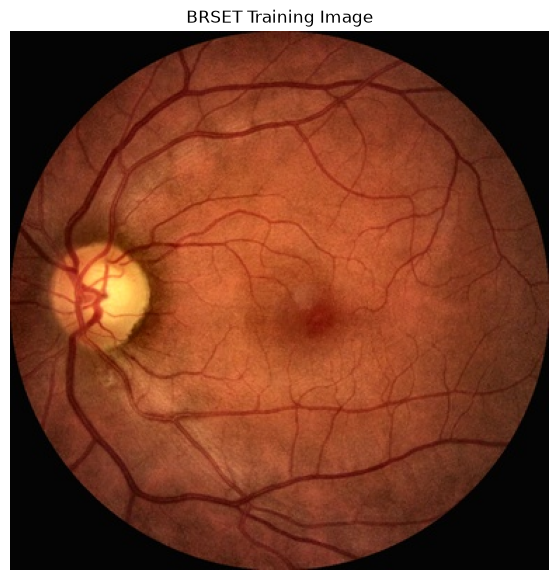

In [19]:
import cv2
import matplotlib.pyplot as plt

image_path = "/mnt/d/projects/college/Rabcl/BRSET_processed/train/1/left.jpg"

img_bgr = cv2.imread(image_path)

if img_bgr is None:
    raise FileNotFoundError(f"Could not read {image_path}")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print("Original image shape:", img_rgb.shape)

plt.figure(figsize=(7, 7))
plt.imshow(img_rgb)
plt.axis("off")
plt.title("BRSET Training Image")
plt.show()

In [20]:
import numpy as np

def pad_to_square(img):
    h, w = img.shape[:2]

    size = max(h, w)

    top = (size - h) // 2
    bottom = size - h - top

    left = (size - w) // 2
    right = size - w - left

    return cv2.copyMakeBorder(
        img,
        top,
        bottom,
        left,
        right,
        cv2.BORDER_CONSTANT,
        value=0
    )


def preprocess_for_sa_unet(img_rgb):
    padded = pad_to_square(img_rgb)

    resized = cv2.resize(
        padded,
        (512, 512),
        interpolation=cv2.INTER_LINEAR
    )

    normalized = resized.astype(np.float32) / 255.0

    model_input = np.expand_dims(
        normalized,
        axis=0
    )

    return model_input

In [21]:
model_input = preprocess_for_sa_unet(img_rgb)

print("Model input shape:", model_input.shape)
print("Minimum:", model_input.min())
print("Maximum:", model_input.max())

Model input shape: (1, 512, 512, 3)
Minimum: 0.0
Maximum: 1.0


In [22]:
prediction = model.predict(
    model_input,
    verbose=1
)

print("Prediction shape:", prediction.shape)

2026-08-28 18:28:43.686080: I external/local_xla/xla/service/service.cc:163] XLA service 0x7efcdc003330 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-08-28 18:28:43.686129: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2026-08-28 18:28:43.724083: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-08-28 18:28:44.177896: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92400
2026-08-28 18:28:45.819547: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.06GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-08-28 18:28:46.33988

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Prediction shape: (1, 512, 512, 1)


I0000 00:00:1787941728.515583    2910 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [23]:
probability_map = prediction[0, :, :, 0]

print("Probability shape:", probability_map.shape)
print("Min probability:", probability_map.min())
print("Max probability:", probability_map.max())

Probability shape: (512, 512)
Min probability: 1.7283216e-09
Max probability: 0.9999976


In [24]:
threshold = 0.5

vessel_mask = (
    probability_map >= threshold
).astype(np.uint8) * 255

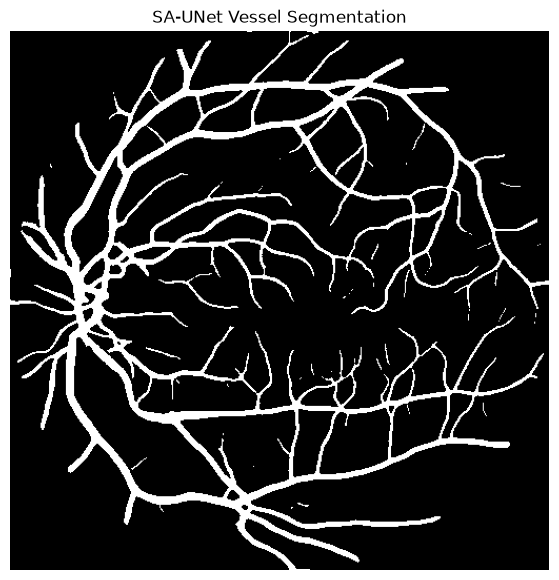

In [26]:
plt.figure(figsize=(7, 7))

plt.imshow(vessel_mask, cmap="gray")
plt.axis("off")
plt.title("SA-UNet Vessel Segmentation")

plt.show()

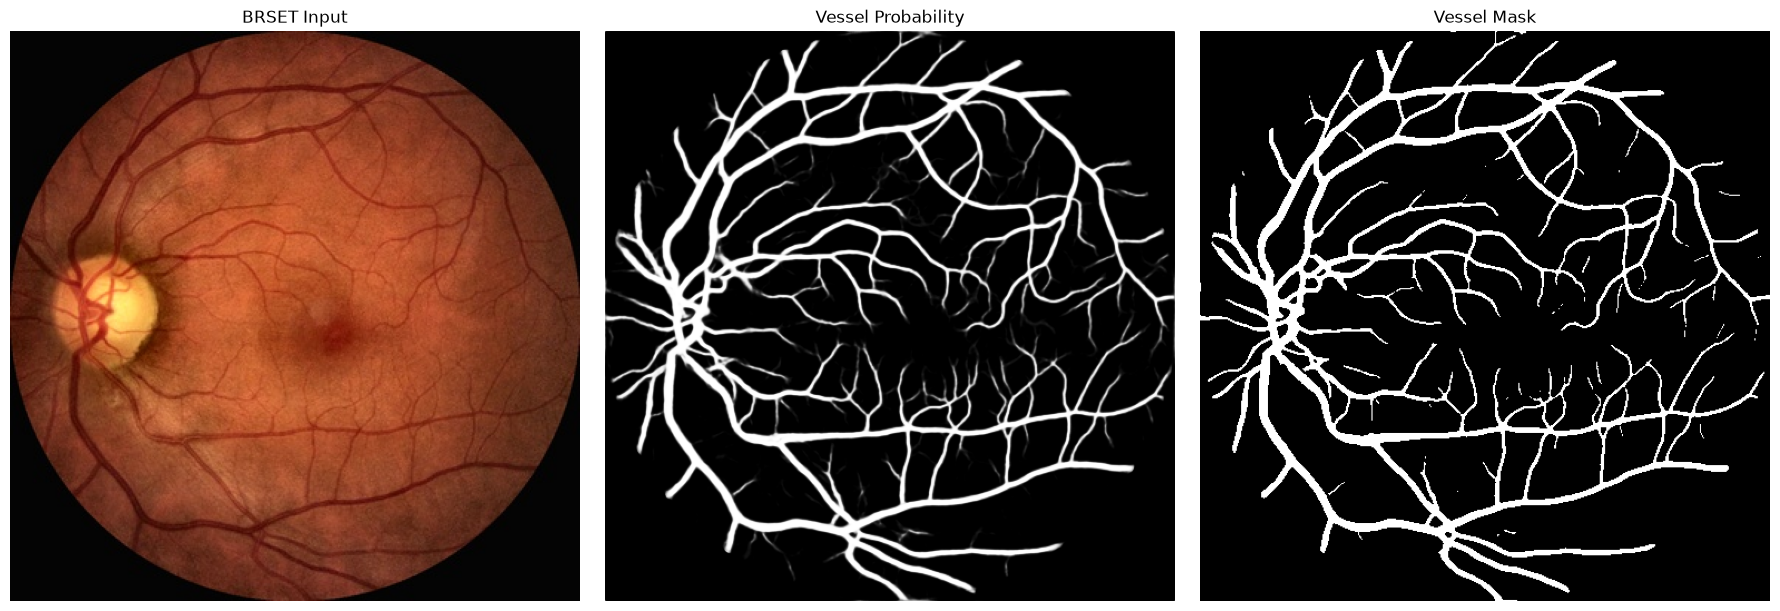

In [27]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("BRSET Input")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(probability_map, cmap="gray")
plt.title("Vessel Probability")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(vessel_mask, cmap="gray")
plt.title("Vessel Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

In [28]:
print("Probability map:")
print("  min =", probability_map.min())
print("  max =", probability_map.max())
print("  mean =", probability_map.mean())

print("\nBinary mask:")
print("  unique values =", np.unique(vessel_mask))

Probability map:
  min = 1.7283216e-09
  max = 0.9999976
  mean = 0.12946089

Binary mask:
  unique values = [  0 255]


In [29]:
# Original image dimensions
original_h, original_w = img_rgb.shape[:2]

# We padded the original image to a square
square_size = max(original_h, original_w)

# Resize the binary prediction back to the padded square size
mask_square = cv2.resize(
    vessel_mask,
    (square_size, square_size),
    interpolation=cv2.INTER_NEAREST
)

# Calculate the padding that was originally added
top = (square_size - original_h) // 2
left = (square_size - original_w) // 2

# Remove the padding
mask_original = mask_square[
    top:top + original_h,
    left:left + original_w
]

print("Original image:", img_rgb.shape)
print("Restored mask :", mask_original.shape)

Original image: (384, 384, 3)
Restored mask : (384, 384)


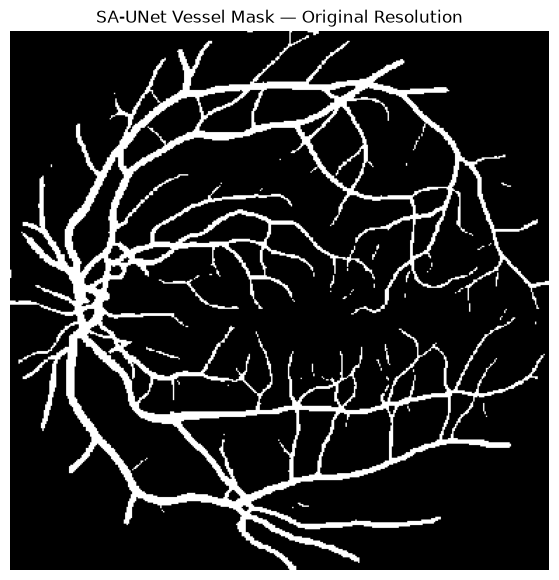

In [30]:
plt.figure(figsize=(10, 7))

plt.imshow(mask_original, cmap="gray")
plt.title("SA-UNet Vessel Mask — Original Resolution")
plt.axis("off")

plt.show()

In [31]:
# Create a copy of the original image
overlay = img_rgb.copy()

# Highlight vessel pixels
vessel_region = mask_original > 0

# Make vessels bright red
overlay[vessel_region] = [255, 0, 0]

# Blend original + vessel overlay
blended = cv2.addWeighted(
    img_rgb,
    0.7,
    overlay,
    0.3,
    0
)

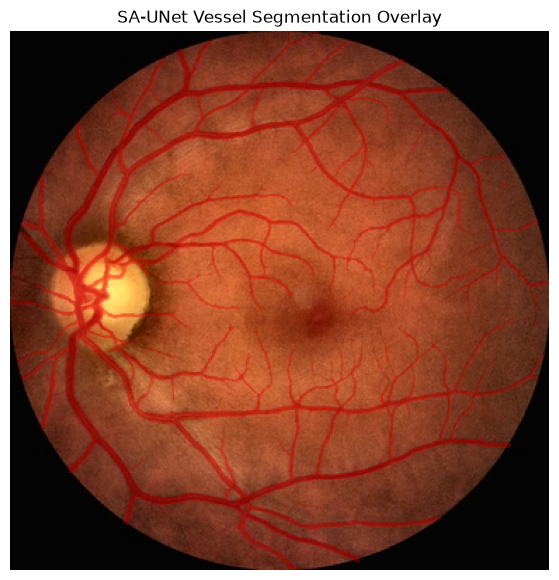

In [32]:
plt.figure(figsize=(10, 7))

plt.imshow(blended)
plt.title("SA-UNet Vessel Segmentation Overlay")
plt.axis("off")

plt.show()

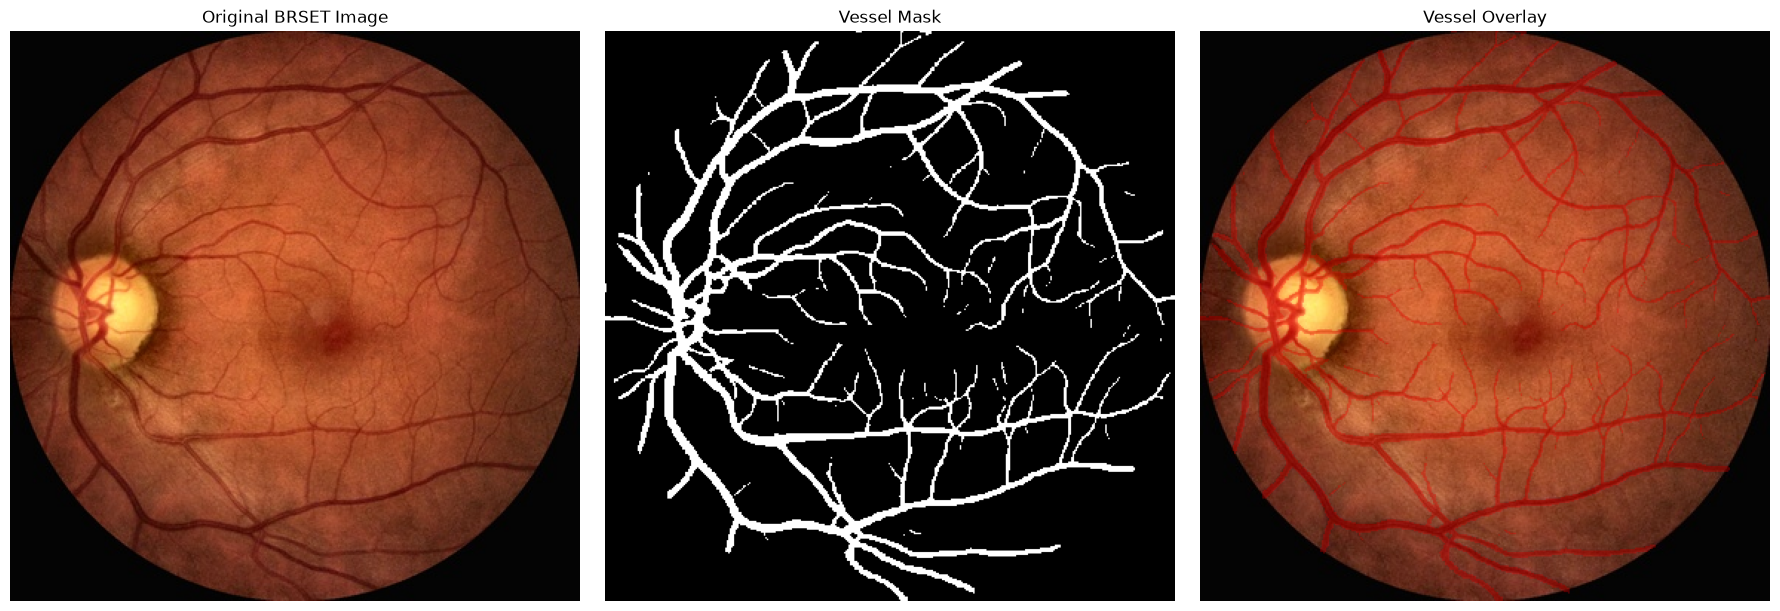

In [33]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Original BRSET Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask_original, cmap="gray")
plt.title("Vessel Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(blended)
plt.title("Vessel Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

In [41]:
!ls BRSET_sample/

ls: cannot access 'BRSET_sample/': No such file or directory


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving img00001.jpg to img00001 (1).jpg
Saving img00002.jpg to img00002.jpg
Saving img00003.jpg to img00003.jpg
Saving img00004.jpg to img00004.jpg
Saving img00005.jpg to img00005.jpg
Saving img00006.jpg to img00006.jpg
Saving img00007.jpg to img00007.jpg
Saving img00008.jpg to img00008.jpg
Saving img00009.jpg to img00009.jpg
Saving img00010.jpg to img00010.jpg
Saving img00011.jpg to img00011.jpg
Saving img00012.jpg to img00012.jpg
Saving img00013.jpg to img00013.jpg
Saving img00014.jpg to img00014.jpg
Saving img00015.jpg to img00015.jpg
Saving img00016.jpg to img00016.jpg
Saving img00019.jpg to img00019.jpg
Saving img00020.jpg to img00020.jpg
Saving img00021.jpg to img00021.jpg
Saving img00022.jpg to img00022.jpg
Saving img00025.jpg to img00025.jpg
Saving img00026.jpg to img00026.jpg
Saving img00027.jpg to img00027.jpg
Saving img00028.jpg to img00028.jpg
Saving img00029.jpg to img00029.jpg
Saving img00030.jpg to img00030.jpg
Saving img00031.jpg to img00031.jpg
Saving img00032.jpg to i

In [ ]:
from google.colab import files

files.upload()

Saving BRSET_first_15_bilateral_patients_30_images_manifest.csv to BRSET_first_15_bilateral_patients_30_images_manifest (1).csv


{'BRSET_first_15_bilateral_patients_30_images_manifest (1).csv': b'patient_id,image_id,eye_label,exam_eye,source_image,target_image,target_mask,quality,camera,vessels\n1,img00001,left,1,img00001.jpg,left.jpg,left_vessel_mask.png,Adequate,Canon CR,1\n1,img00002,right,2,img00002.jpg,right.jpg,right_vessel_mask.png,Adequate,Canon CR,1\n2,img00003,left,1,img00003.jpg,left.jpg,left_vessel_mask.png,Adequate,Canon CR,1\n2,img00004,right,2,img00004.jpg,right.jpg,right_vessel_mask.png,Adequate,Canon CR,1\n3,img00005,left,1,img00005.jpg,left.jpg,left_vessel_mask.png,Adequate,Canon CR,1\n3,img00006,right,2,img00006.jpg,right.jpg,right_vessel_mask.png,Adequate,Canon CR,1\n4,img00007,left,1,img00007.jpg,left.jpg,left_vessel_mask.png,Adequate,Canon CR,1\n4,img00008,right,2,img00008.jpg,right.jpg,right_vessel_mask.png,Adequate,Canon CR,1\n5,img00009,left,1,img00009.jpg,left.jpg,left_vessel_mask.png,Adequate,Canon CR,1\n5,img00010,right,2,img00010.jpg,right.jpg,right_vessel_mask.png,Adequate,Canon CR,

In [36]:
import pandas as pd

MANIFEST_PATH = "/mnt/d/projects/college/Rabcl/preprocessed.csv"
manifest = pd.read_csv(MANIFEST_PATH)

required_columns = {"patient_id", "exam_eye"}
missing_columns = required_columns.difference(manifest.columns)
if missing_columns:
    raise ValueError(f"Manifest is missing required columns: {sorted(missing_columns)}")

print("Manifest:", MANIFEST_PATH)
print("Rows:", len(manifest))

Manifest: /mnt/d/projects/college/Rabcl/preprocessed.csv
Rows: 12164


In [38]:
import os
import cv2
import numpy as np
from tqdm.auto import tqdm

BRSET_DIR = r"/mnt/d/projects/college/Rabcl/BRSET_processed/train"
MASKS_OUTPUT = r"/mnt/d/projects/college/Rabcl/masks_output"

os.makedirs(MASKS_OUTPUT, exist_ok=True)

print("Input directory:", BRSET_DIR)
print("Mask output directory:", MASKS_OUTPUT)

Input directory: /mnt/d/projects/college/Rabcl/BRSET_processed/train
Mask output directory: /mnt/d/projects/college/Rabcl/masks_output


In [39]:
new_masks = 0
skipped_masks = 0
failed_images = 0

eye_to_filename = {
    "left": "Left_vessel.png",
    "right": "Right_vessel.png",
}

for _, row in tqdm(
    manifest.iterrows(),
    total=len(manifest),
    desc="Processing BRSET images"
):
    patient_id = str(row["patient_id"]).strip()
    eye = str(row["exam_eye"]).strip().lower()

    if eye not in eye_to_filename:
        failed_images += 1
        print(f"Unsupported exam_eye for patient {patient_id}: {row['exam_eye']!r}")
        continue

    image_path = os.path.join(BRSET_DIR, patient_id, eye + ".jpg")
    patient_folder = os.path.join(MASKS_OUTPUT, patient_id)
    output_mask_path = os.path.join(patient_folder, eye_to_filename[eye])

    if os.path.exists(output_mask_path):
        skipped_masks += 1
        continue

    try:
        img_bgr = cv2.imread(image_path)
        if img_bgr is None:
            raise FileNotFoundError(f"Could not read image: {image_path}")

        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        original_h, original_w = img_rgb.shape[:2]

        model_input = preprocess_for_sa_unet(img_rgb)
        prediction = model.predict(model_input, verbose=0)[0, :, :, 0]
        mask_512 = (prediction >= 0.5).astype(np.uint8) * 255

        square_size = max(original_h, original_w)
        mask_square = cv2.resize(
            mask_512,
            (square_size, square_size),
            interpolation=cv2.INTER_NEAREST
        )

        top = (square_size - original_h) // 2
        left = (square_size - original_w) // 2
        mask_original = mask_square[
            top:top + original_h,
            left:left + original_w
        ]

        os.makedirs(patient_folder, exist_ok=True)
        if not cv2.imwrite(output_mask_path, mask_original):
            raise IOError(f"Could not write mask: {output_mask_path}")

        new_masks += 1
    except Exception as error:
        failed_images += 1
        print(f"Failed patient {patient_id}, {eye}: {error}")

print("\nTotal images in manifest:", len(manifest))
print("Total patients:", manifest["patient_id"].nunique())
print("New masks generated:", new_masks)
print("Already existed/skipped:", skipped_masks)
print("Failed:", failed_images)
print("Final output directory:", MASKS_OUTPUT)

Processing BRSET images:   0%|          | 0/12164 [00:00<?, ?it/s]


Total images in manifest: 12164
Total patients: 6082
New masks generated: 12164
Already existed/skipped: 0
Failed: 0
Final output directory: /mnt/d/projects/college/Rabcl/masks_output


In [ ]:
import os
import glob

patient_dirs = sorted(
    glob.glob("/content/BRSET_SAUNet_sample/patient_*")
)

print("Patient folders:", len(patient_dirs))

for folder in patient_dirs:
    files = sorted(os.listdir(folder))
    print(os.path.basename(folder), "→", files)

Patient folders: 15
patient_00001 → ['left.jpg', 'left_vessel_mask.png', 'right.jpg', 'right_vessel_mask.png']
patient_00002 → ['left.jpg', 'left_vessel_mask.png', 'right.jpg', 'right_vessel_mask.png']
patient_00003 → ['left.jpg', 'left_vessel_mask.png', 'right.jpg', 'right_vessel_mask.png']
patient_00004 → ['left.jpg', 'left_vessel_mask.png', 'right.jpg', 'right_vessel_mask.png']
patient_00005 → ['left.jpg', 'left_vessel_mask.png', 'right.jpg', 'right_vessel_mask.png']
patient_00006 → ['left.jpg', 'left_vessel_mask.png', 'right.jpg', 'right_vessel_mask.png']
patient_00007 → ['left.jpg', 'left_vessel_mask.png', 'right.jpg', 'right_vessel_mask.png']
patient_00008 → ['left.jpg', 'left_vessel_mask.png', 'right.jpg', 'right_vessel_mask.png']
patient_00010 → ['left.jpg', 'left_vessel_mask.png', 'right.jpg', 'right_vessel_mask.png']
patient_00011 → ['left.jpg', 'left_vessel_mask.png', 'right.jpg', 'right_vessel_mask.png']
patient_00013 → ['left.jpg', 'left_vessel_mask.png', 'right.jpg', 'rig

In [44]:
import matplotlib.pyplot as plt
import cv2
import os
import math

rows = []

eye_to_filename = {
    "left": "Left_vessel.png",
    "right": "Right_vessel.png",
}

for _, row in manifest.iterrows():

    patient_id = str(row["patient_id"]).strip()
    eye = str(row["exam_eye"]).strip().lower()

    if eye not in eye_to_filename:
        continue

    image_path = os.path.join(
        BRSET_DIR,
        patient_id,
        eye + ".jpg"
    )

    mask_path = os.path.join(
        MASKS_OUTPUT,
        patient_id,
        eye_to_filename[eye]
    )

    img_bgr = cv2.imread(image_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if img_bgr is None or mask is None:
        continue

    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    rows.append(
        (patient_id, eye, img, mask)
    )
print("Loaded:", len(rows), "images")

: 

In [ ]:
def create_overlay(img, mask):

    overlay = img.copy()

    vessel_pixels = mask > 0

    # Highlight predicted vessels
    overlay[vessel_pixels] = [255, 0, 0]

    blended = cv2.addWeighted(
        img,
        0.7,
        overlay,
        0.3,
        0
    )

    return blended

In [ ]:
def show_batch(start, batch_size=5):

    batch = rows[start:start + batch_size]

    fig, axes = plt.subplots(
        len(batch),
        3,
        figsize=(15, 4 * len(batch))
    )

    if len(batch) == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, (patient_id, eye, img, mask) in enumerate(batch):

        overlay = create_overlay(img, mask)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title(
            f"Patient {patient_id:05d} - {eye}\nOriginal"
        )
        axes[i, 0].axis("off")

        axes[i, 1].imshow(mask, cmap="gray")
        axes[i, 1].set_title("Vessel Mask")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title("Overlay")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()

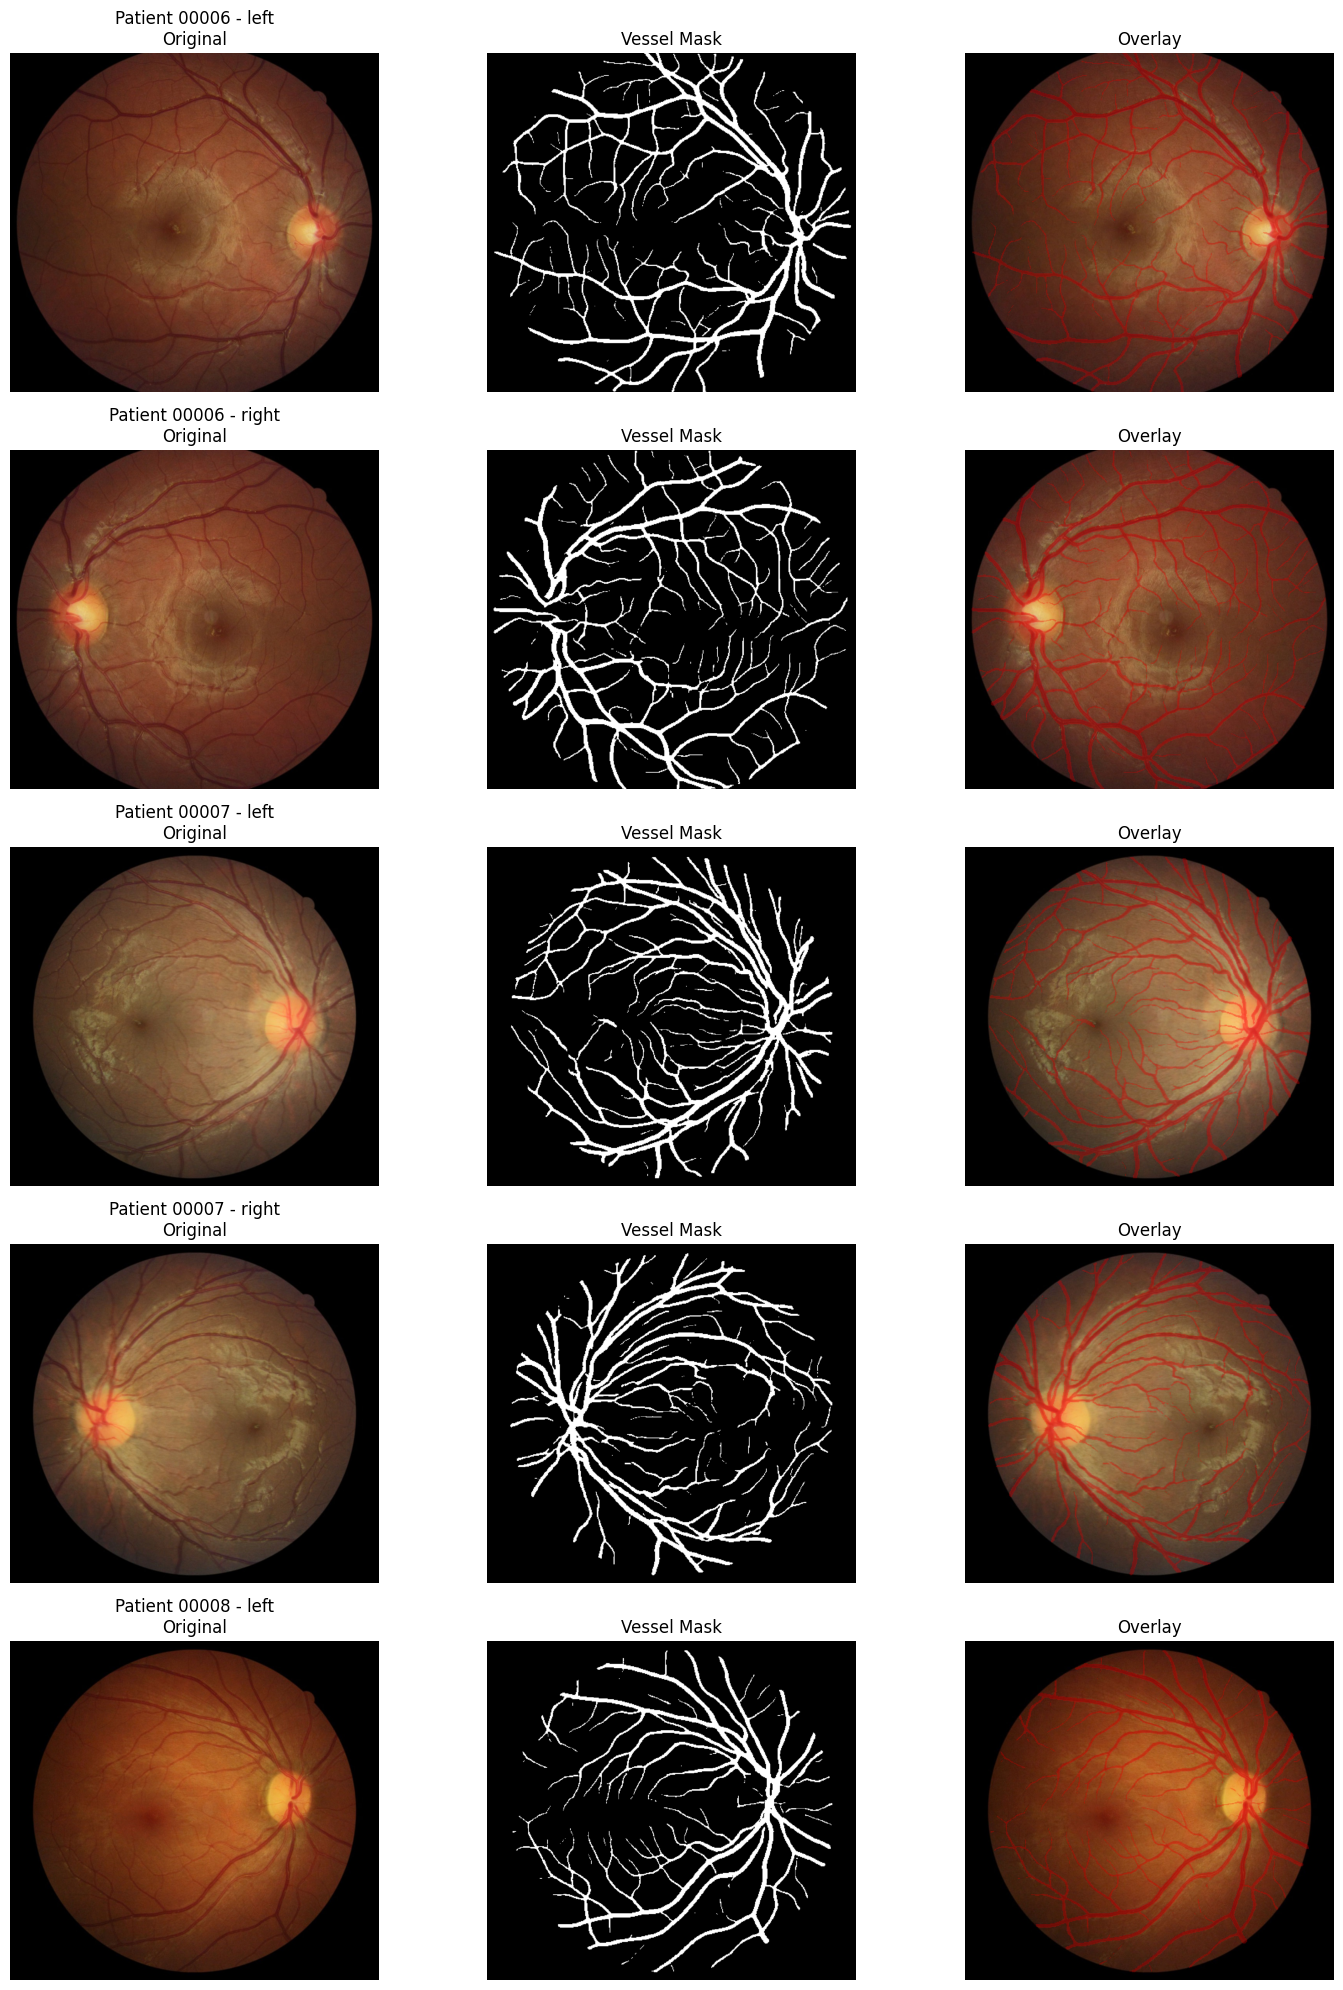

In [ ]:
show_batch(10)

In [40]:
def predict_vessel_mask(img_rgb, threshold=0.5):

    original_h, original_w = img_rgb.shape[:2]

    # Use your existing preprocessing
    model_input = preprocess_for_sa_unet(img_rgb)

    prediction = model.predict(
        model_input,
        verbose=0
    )[0, :, :, 0]

    mask_512 = (
        prediction >= threshold
    ).astype(np.uint8)

    # Restore to original image dimensions
    square_size = max(
        original_h,
        original_w
    )

    mask_square = cv2.resize(
        mask_512,
        (square_size, square_size),
        interpolation=cv2.INTER_NEAREST
    )

    top = (square_size - original_h) // 2
    left = (square_size - original_w) // 2

    mask_original = mask_square[
        top:top + original_h,
        left:left + original_w
    ]

    return mask_original

In [41]:
def tta_images(img_rgb):

    images = {}

    # Original
    images["original"] = img_rgb.copy()

    # Brightness increase
    brighter = cv2.convertScaleAbs(
        img_rgb,
        alpha=1.0,
        beta=15
    )

    images["brightness_up"] = brighter

    # Brightness decrease
    darker = cv2.convertScaleAbs(
        img_rgb,
        alpha=1.0,
        beta=-15
    )

    images["brightness_down"] = darker

    # Mild contrast change
    contrast = cv2.convertScaleAbs(
        img_rgb,
        alpha=1.10,
        beta=0
    )

    images["contrast"] = contrast

    # Mild Gaussian noise
    noise = np.random.normal(
        0,
        5,
        img_rgb.shape
    )

    noisy = np.clip(
        img_rgb.astype(np.float32) + noise,
        0,
        255
    ).astype(np.uint8)

    images["noise"] = noisy

    return images

In [42]:
def dice_score(mask_a, mask_b):

    mask_a = mask_a.astype(bool)
    mask_b = mask_b.astype(bool)

    intersection = np.logical_and(
        mask_a,
        mask_b
    ).sum()

    denominator = (
        mask_a.sum() +
        mask_b.sum()
    )

    if denominator == 0:
        return 1.0

    return (
        2.0 * intersection /
        denominator
    )


def iou_score(mask_a, mask_b):

    mask_a = mask_a.astype(bool)
    mask_b = mask_b.astype(bool)

    intersection = np.logical_and(
        mask_a,
        mask_b
    ).sum()

    union = np.logical_or(
        mask_a,
        mask_b
    ).sum()

    if union == 0:
        return 1.0

    return intersection / union

In [43]:
patient_id, eye, img, original_saved_mask = rows[0]

tta = tta_images(img)

tta_masks = {}

for name, transformed_img in tta.items():

    tta_masks[name] = predict_vessel_mask(
        transformed_img
    )

print("TTA predictions generated:")
print(list(tta_masks.keys()))

NameError: name 'rows' is not defined

In [ ]:
names = list(tta_masks.keys())

dice_values = []
iou_values = []

for i in range(len(names)):

    for j in range(i + 1, len(names)):

        a = tta_masks[names[i]]
        b = tta_masks[names[j]]

        dice = dice_score(a, b)
        iou = iou_score(a, b)

        dice_values.append(dice)
        iou_values.append(iou)

        print(
            f"{names[i]:16s} vs "
            f"{names[j]:16s} | "
            f"Dice = {dice:.4f} | "
            f"IoU = {iou:.4f}"
        )

print("\nMean Dice:", np.mean(dice_values))
print("Mean IoU :", np.mean(iou_values))

original         vs brightness_up    | Dice = 0.9833 | IoU = 0.9672
original         vs brightness_down  | Dice = 0.9297 | IoU = 0.8687
original         vs contrast         | Dice = 0.9831 | IoU = 0.9668
original         vs noise            | Dice = 0.9232 | IoU = 0.8574
brightness_up    vs brightness_down  | Dice = 0.9369 | IoU = 0.8813
brightness_up    vs contrast         | Dice = 0.9861 | IoU = 0.9726
brightness_up    vs noise            | Dice = 0.9283 | IoU = 0.8662
brightness_down  vs contrast         | Dice = 0.9315 | IoU = 0.8717
brightness_down  vs noise            | Dice = 0.9025 | IoU = 0.8223
contrast         vs noise            | Dice = 0.9237 | IoU = 0.8582

Mean Dice: 0.9428432426461463
Mean IoU : 0.8932532287629276


In [ ]:
results = []

for patient_id, eye, img, saved_mask in rows:

    tta = tta_images(img)

    tta_masks = {}

    for name, transformed_img in tta.items():

        tta_masks[name] = predict_vessel_mask(
            transformed_img
        )

    names = list(tta_masks.keys())

    dice_values = []
    iou_values = []

    for i in range(len(names)):

        for j in range(i + 1, len(names)):

            dice_values.append(
                dice_score(
                    tta_masks[names[i]],
                    tta_masks[names[j]]
                )
            )

            iou_values.append(
                iou_score(
                    tta_masks[names[i]],
                    tta_masks[names[j]]
                )
            )

    results.append({
        "patient_id": patient_id,
        "eye": eye,
        "mean_tta_dice": np.mean(dice_values),
        "mean_tta_iou": np.mean(iou_values),
        "min_tta_dice": np.min(dice_values),
        "min_tta_iou": np.min(iou_values)
    })

tta_results = pd.DataFrame(results)

display(tta_results)

,patient_id,eye,mean_tta_dice,mean_tta_iou,min_tta_dice,min_tta_iou
0,1,left,0.942494,0.892646,0.902918,0.823018
1,1,right,0.951329,0.908670,0.912876,0.839716
2,2,left,0.924471,0.861735,0.886064,0.795435
3,2,right,0.935637,0.880715,0.905283,0.826956
4,3,left,0.958253,0.921148,0.917106,0.846903
5,3,right,0.952431,0.910658,0.909231,0.833569
6,4,left,0.975690,0.953148,0.951909,0.908231
7,4,right,0.976228,0.954192,0.951809,0.908050
8,5,left,0.944076,0.895019,0.921122,0.853777
9,5,right,0.953929,0.912803,0.925217,0.860841
